# Cleaning the Data
-  data cleaning of demo + experiment files

In [1486]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os

In [1487]:
os.getcwd()  # this prints your current working directory

'/Users/hanane/Ironhack/local_vanguard_abtest_project'

In [1488]:
os.listdir('raw_data')

['df_final_experiment_clients.csv',
 'df_final_demo.csv',
 'df_final_web_data_pt_1.csv',
 'df_final_web_data_pt_2.csv']

In [1489]:
df_demo = pd.read_csv('raw_data/df_final_demo.csv')
df_exp = pd.read_csv('raw_data/df_final_experiment_clients.csv')
df_web1 = pd.read_csv('raw_data/df_final_web_data_pt_1.csv')
df_web2 = pd.read_csv('raw_data/df_final_web_data_pt_2.csv')

In [1490]:
df_demo.head(5)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


## df_exp cleaning

In [1491]:
df_exp.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [1492]:
df_exp.columns = df_exp.columns.str.lower().str.strip()

In [1493]:
df_exp.isnull().sum()

client_id        0
variation    20109
dtype: int64

In [1494]:
df_exp = df_exp.dropna(subset=['variation'])
df_exp.isnull().sum()

client_id    0
variation    0
dtype: int64

In [1495]:
df_exp.variation.value_counts()

variation
Test       26968
Control    23532
Name: count, dtype: int64

In [1496]:
df_exp.duplicated().sum()

np.int64(0)

## df_web cleaning

In [1497]:
df_web1.head(3)

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22


In [1498]:
df_web2.head(3)

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48


In [1499]:
#merging the two web datasets
df_web = pd.concat([df_web1, df_web2], axis=0 )

In [1500]:
df_web.shape

(755405, 5)

In [1501]:
df_web.duplicated().sum()

np.int64(10764)

In [1502]:
df_web = df_web.drop_duplicates()
df_web.duplicated().sum()

np.int64(0)

In [1503]:
df_web.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [1504]:
df_web.dtypes

client_id        int64
visitor_id      object
visit_id        object
process_step    object
date_time       object
dtype: object

In [1505]:
df_web['date_time'] =pd.to_datetime(df_web['date_time'])
print(df_web.date_time.dtype)

datetime64[ns]


In [1506]:
df_web['process_step'].value_counts()

process_step
start      234999
step_1     162797
step_2     132750
step_3     111589
confirm    102506
Name: count, dtype: int64

In [1507]:
df_web.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [1508]:
df_web.head(10)

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
5,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:17:15
6,9988021,580560515_7732621733,781255054_21935453173_531117,step_1,2017-04-17 15:17:01
7,9988021,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17 15:16:22
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05
9,8320017,39393514_33118319366,960651974_70596002104_312201,step_3,2017-04-05 13:09:43


## Cleaning df_demo

In [1509]:
df_demo = df_demo.dropna()

In [1510]:
df_demo = df_demo[df_demo['gendr'].isin(['M', 'F', 'U'])]

### Univariate analysis on df_demo

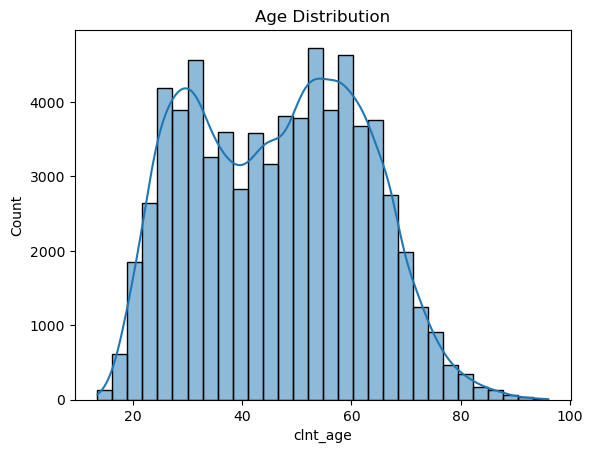

In [1511]:
sns.histplot(df_demo['clnt_age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()  # ← force display

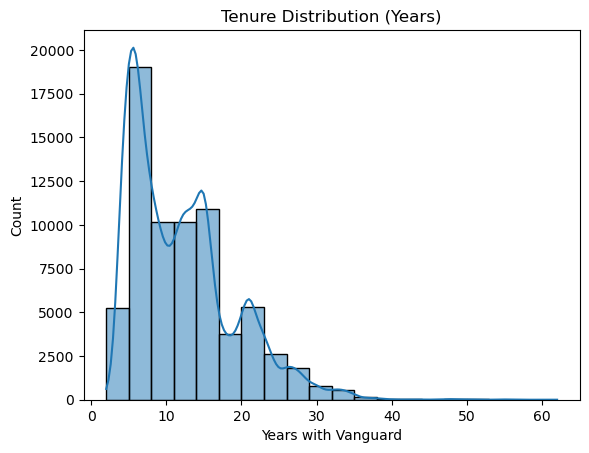

In [1512]:
sns.histplot(df_demo['clnt_tenure_yr'], bins=20, kde=True)
plt.title('Tenure Distribution (Years)')
plt.xlabel('Years with Vanguard')
plt.show()

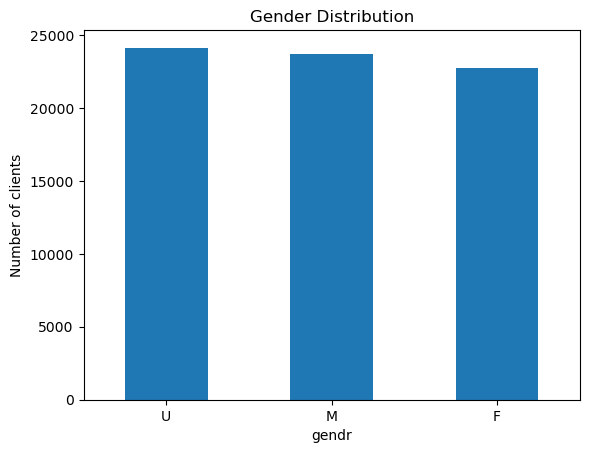

In [1513]:
df_demo['gendr'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.ylabel('Number of clients')
plt.xticks(rotation=0)
plt.show()

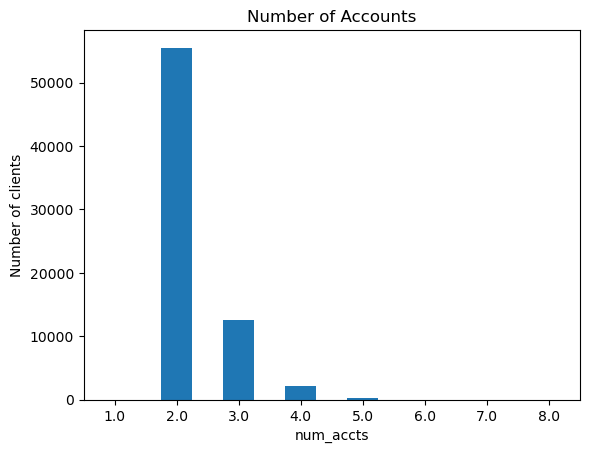

In [1514]:
df_demo['num_accts'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Accounts')
plt.ylabel('Number of clients')
plt.xticks(rotation=0)
plt.show()

#### Question 1 : Who are the primary clients?

In [1515]:
print(f"Average age:{df_demo['clnt_age'].mean():.1f} years")
print(f"Average tenure:    {df_demo['clnt_tenure_yr'].mean():.1f} years")
print(f"Average balance:   ${df_demo['bal'].mean():,.0f}")
print(f"Average accounts:  {df_demo['num_accts'].mean():.1f}")
print(f"Average logons:    {df_demo['logons_6_mnth'].mean():.1f} per 6 months")
print('----')
print("Gender split:")
print((df_demo['gendr'].value_counts(normalize=True) * 100).round(1))

Average age:46.4 years
Average tenure:    12.1 years
Average balance:   $147,452
Average accounts:  2.3
Average logons:    5.6 per 6 months
----
Gender split:
gendr
U    34.2
M    33.6
F    32.2
Name: proportion, dtype: float64


#### Question 2 : Younger or older? New or long-standing?

In [1516]:
df_demo['age_group'] = pd.cut(
    df_demo['clnt_age'],
    bins=[18, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+']
)
print((df_demo['age_group'].value_counts(normalize = True)*100).round(1))

age_group
46-60    31.5
31-45    27.1
60+      22.1
18-30    19.3
Name: proportion, dtype: float64


In [1517]:
df_demo['tenure_group'] = pd.cut(
    df_demo['clnt_tenure_yr'],
    bins=[0, 5, 10, 100],
    labels=['New (0-5y)', 'Established (5-10y)', 'Loyal (10y+)']
)
print((df_demo['tenure_group'].value_counts(normalize = True)*100).round(1))

tenure_group
Loyal (10y+)           51.3
Established (5-10y)    31.5
New (0-5y)             17.2
Name: proportion, dtype: float64


In [1518]:
df_demo.tenure_group.value_counts()

tenure_group
Loyal (10y+)           36198
Established (5-10y)    22221
New (0-5y)             12172
Name: count, dtype: int64

## Merging df_web and df_exp

In [1519]:
df= df_exp.merge(df_web, on='client_id', how='inner')
print(df.shape)

(317235, 6)


In [1520]:
df.variation.value_counts()

variation
Test       176699
Control    140536
Name: count, dtype: int64

In [1521]:
df.head(10)

,client_id,variation,visitor_id,visit_id,process_step,date_time
0,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
5,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:17:15
6,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_1,2017-04-17 15:17:01
7,9988021,Test,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17 15:16:22
8,9988021,Test,580560515_7732621733,219729223_42518459208_211914,start,2017-04-12 18:54:43
9,9988021,Test,580560515_7732621733,219729223_42518459208_211914,start,2017-04-12 18:38:42


#### Average balance by age group

In [1522]:
#df_demo.groupby('age_group')['bal'].mean().round(0).plot(kind='bar', color='pink')
#plt.title('Average Balance by Age Group')

# Completion rate
reached "confirm" 
gone through all the step in the right order
loops are accepted

In [1523]:
df.head(3)

,client_id,variation,visitor_id,visit_id,process_step,date_time
0,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,Test,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22


In [1524]:
df_sorted = df.sort_values(['visit_id', 'date_time'])

In [1525]:
ordered_steps = df_sorted.groupby('visit_id')['process_step'].apply(list)

In [1526]:
required_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

def is_complete_in_order(steps_sequence, required=required_order):
    """
    Returns True if the required steps appear in the correct order
    within the user's sequence. Repeats and loops are allowed between steps.
    """
    required_index = 0
    
    for step in steps_sequence:
        if step == required[required_index]:
            required_index += 1
            if required_index == len(required):
                return True
    
    return False

In [1527]:
completed = ordered_steps.apply(is_complete_in_order)
completed.head()

visit_id
100012776_37918976071_457913    False
100019538_17884295066_43909      True
100022086_87870757897_149620     True
100030127_47967100085_936361    False
100037962_47432393712_705583    False
Name: process_step, dtype: bool

In [1528]:
completion_rate = completed.mean()
completion_rate

np.float64(0.4700816414998916)

In [1529]:
df_sorted.columns

Index(['client_id', 'variation', 'visitor_id', 'visit_id', 'process_step',
       'date_time'],
      dtype='object')

In [1530]:
completion_rate_by_variation = completed.groupby(df_sorted.groupby('visit_id')['variation'].first()).mean()
completion_rate_by_variation

variation
Control    0.458562
Test       0.480059
Name: process_step, dtype: float64

In [1531]:
completion_rate_v2 = (completion_rate_by_variation * 100).round(2)
completion_rate_v2

variation
Control    45.86
Test       48.01
Name: process_step, dtype: float64

# Time spent per step

In [1532]:
df_web.shape

(744641, 5)

In [1533]:
# Sort chronologically
df = df_web.sort_values(['visit_id', 'date_time'])
df.head(5)

,client_id,visitor_id,visit_id,process_step,date_time
108614,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17
108613,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09
104810,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29
104809,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32
104808,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56


In [1534]:
df['next_time'] = df.groupby('visit_id')['date_time'].shift(-1)

In [1535]:
df['time_spent_clean'] = (df['next_time'] - df['date_time']).dt.total_seconds()

In [1536]:
df.head(5)

,client_id,visitor_id,visit_id,process_step,date_time,next_time,time_spent_clean
108614,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,2017-04-26 13:23:09,52.0
108613,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,NaT,NaN
104810,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29,2017-06-04 01:07:32,3.0
104809,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32,2017-06-04 01:07:56,24.0
104808,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56,2017-06-04 01:09:13,77.0


In [1537]:
# handeling last step ( confirm) 
df = df[df['time_spent_clean'].notna()]

In [1538]:
# fixing repeated steps
step_time_per_visit = (
    df.groupby(['visit_id', 'process_step'])['time_spent_clean']
    .sum()
    .reset_index())

In [1539]:
df.head(5)

,client_id,visitor_id,visit_id,process_step,date_time,next_time,time_spent_clean
108614,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,2017-04-26 13:23:09,52.0
104810,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29,2017-06-04 01:07:32,3.0
104809,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32,2017-06-04 01:07:56,24.0
104808,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56,2017-06-04 01:09:13,77.0
104807,9056452,306992881_89423906595,1000165_4190026492_760066,step_3,2017-06-04 01:09:13,2017-06-04 01:09:50,37.0


In [1540]:
# final aggregation
final_step_time = (step_time_per_visit.groupby('process_step')['time_spent_clean']
                   .mean()
                   .reset_index())
final_step_time

,process_step,time_spent_clean
0,confirm,361.937799
1,start,92.554062
2,step_1,82.310723
3,step_2,117.779976
4,step_3,154.482465


In [1541]:
#handeling the loop ( step1-step2-step1) 
#df_first = df.drop_duplicates(subset=['visit_id', 'process_step'], keep='first')

# Error rate 

In [1542]:
df_sorted = df.sort_values(['visit_id', 'date_time']).reset_index(drop=True)

In [1543]:
# 2. Map each step to a numeric rank
step_rank = {'start': 0, 'step_1': 1, 'step_2': 2, 'step_3': 3, 'confirm': 4}
df_sorted['step_rank'] = df_sorted['process_step'].map(step_rank)

In [1544]:
# 3. Get the previous step and its rank within each visit
df_sorted['prev_step'] = df_sorted.groupby('visit_id')['process_step'].shift(1)
df_sorted['prev_rank'] = df_sorted.groupby('visit_id')['step_rank'].shift(1)

In [1545]:
df_sorted.head(5)

,client_id,visitor_id,visit_id,process_step,date_time,next_time,time_spent_clean,step_rank,prev_step,prev_rank
0,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,2017-04-26 13:23:09,52.0,4,NaN,NaN
1,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29,2017-06-04 01:07:32,3.0,0,NaN,NaN
2,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32,2017-06-04 01:07:56,24.0,1,start,0.0
3,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56,2017-06-04 01:09:13,77.0,2,step_1,1.0
4,9056452,306992881_89423906595,1000165_4190026492_760066,step_3,2017-06-04 01:09:13,2017-06-04 01:09:50,37.0,3,step_2,2.0


In [1546]:
# 4. Compute backward distance (weighted: step_3 -> step_1 = 2 errors)
df_sorted['backward_distance'] = df_sorted['prev_rank'] - df_sorted['step_rank']
df_sorted.loc[df_sorted['backward_distance'] < 0, 'backward_distance'] = 0
df_sorted['backward_distance'] = df_sorted['backward_distance'].fillna(0)

In [1550]:
df_sorted.head(5)

,client_id,visitor_id,visit_id,process_step,date_time,next_time,time_spent_clean,step_rank,prev_step,prev_rank,backward_distance
0,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,2017-04-26 13:23:09,52.0,4,NaN,NaN,0.0
1,9056452,306992881_89423906595,1000165_4190026492_760066,start,2017-06-04 01:07:29,2017-06-04 01:07:32,3.0,0,NaN,NaN,0.0
2,9056452,306992881_89423906595,1000165_4190026492_760066,step_1,2017-06-04 01:07:32,2017-06-04 01:07:56,24.0,1,start,0.0,0.0
3,9056452,306992881_89423906595,1000165_4190026492_760066,step_2,2017-06-04 01:07:56,2017-06-04 01:09:13,77.0,2,step_1,1.0,0.0
4,9056452,306992881_89423906595,1000165_4190026492_760066,step_3,2017-06-04 01:09:13,2017-06-04 01:09:50,37.0,3,step_2,2.0,0.0


In [1556]:
len(df_sorted)

586546

In [1557]:
df_sorted['backward_distance'].sum()

np.float64(68722.0)

In [1558]:
# A.Overall weighted error rate
overall_error_rate = df_sorted['backward_distance'].sum()*100 / len(df_sorted)
overall_error_rate

np.float64(11.716387120532746)

In [1559]:
# B. Overall error rate per variation
error_by_variation = df_sorted.groupby('variation')['backward_distance'].mean()


KeyError: 'variation'